# Cricket Hot Match Analysis

**HOT matches** (known exciting, used as positive examples):
- **DC vs GT, IPL 2026, Apr 8** — GT won by 1 run (last ball finish)
- **IND vs PAK, T20 WC 2024, Jun 9** — India won by 6 runs defending 119

**COLD matches** (one-sided, used as negative examples):
- **RR vs MI, IPL 2026, Apr 7** — RR won by 27 runs (rain-reduced, 11 overs)
- **MI vs RR, IPL 2025, May 1** — MI won by 100 runs

Goal: derive ball-by-ball signals that separate hot from cold.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

FIG_DIR = Path('../data/figures/01_match_analysis')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
def load_match(path):
    with open(path) as f:
        return json.load(f)

def parse_innings(match_data, innings_idx):
    """Flatten one innings into a ball-by-ball DataFrame."""
    rows = []
    inn = match_data['innings'][innings_idx]
    team = inn['team']
    cumulative = 0
    wickets = 0
    legal_ball = 0  # counts only legal deliveries (no wides/no-balls for ball count)

    for over_data in inn['overs']:
        over_num = over_data['over']  # 0-indexed
        for delivery in over_data['deliveries']:
            runs_total = delivery['runs']['total']
            is_wicket = 'wickets' in delivery
            extras = delivery['runs'].get('extras', 0)
            extras_type = list(delivery.get('extras', {}).keys()) if 'extras' in delivery else []
            is_legal = not any(e in extras_type for e in ['wides', 'noballs'])

            cumulative += runs_total
            if is_wicket:
                wickets += len(delivery['wickets'])
            if is_legal:
                legal_ball += 1

            rows.append({
                'team': team,
                'over': over_num,
                'over_display': over_num + 1,  # 1-indexed for display
                'legal_ball': legal_ball,       # balls 1..120
                'batter': delivery['batter'],
                'bowler': delivery['bowler'],
                'runs': runs_total,
                'batter_runs': delivery['runs']['batter'],
                'extras': extras,
                'extras_type': extras_type,
                'is_legal': is_legal,
                'is_wicket': is_wicket,
                'wickets_fallen': wickets,
                'score': cumulative,
            })

    df = pd.DataFrame(rows)
    return df

def parse_match(path):
    """Returns meta + innings DataFrames."""
    data = load_match(path)
    meta = {
        'teams': data['info']['teams'],
        'dates': data['info']['dates'],
        'toss': data['info']['toss'],
        'outcome': data['info'].get('outcome', {}),
    }
    innings = [parse_innings(data, i) for i in range(len(data['innings']))]
    return meta, innings

In [3]:
dc_gt_meta, dc_gt_innings = parse_match('../data/raw/dc_vs_gt_2026-04-08.json')
ind_pak_meta, ind_pak_innings = parse_match('../data/raw/ind_vs_pak_2024-06-09.json')
rr_mi_meta, rr_mi_innings = parse_match('../data/raw/rr_vs_mi_2026-04-07.json')
mi_rr_meta, mi_rr_innings = parse_match('../data/raw/mi_vs_rr_2025-05-01.json')

print('DC vs GT:', dc_gt_meta['outcome'])
print('IND vs PAK:', ind_pak_meta['outcome'])
print('RR vs MI (2026):', rr_mi_meta['outcome'])
print('MI vs RR (2025):', mi_rr_meta['outcome'])

DC vs GT: {'winner': 'Gujarat Titans', 'by': {'runs': 1}}
IND vs PAK: {'winner': 'India', 'by': {'runs': 6}}
RR vs MI (2026): {'winner': 'Rajasthan Royals', 'by': {'runs': 27}}
MI vs RR (2025): {'winner': 'Mumbai Indians', 'by': {'runs': 100}}


## Compute Chase Metrics (2nd Innings)

The chase is where matches become hot. Key metrics per legal ball:
- **target**: runs needed at start
- **runs_needed**: runs remaining
- **balls_remaining**: legal balls left (120 total)
- **rrr**: required run rate (per ball)
- **crr**: current run rate (per ball so far)
- **pressure**: rrr / crr — >1 means chasing team is behind
- **win_prob**: simple model based on historical T20 run-scoring distributions
- **momentum_shift**: abs change in win_prob over last 6 balls

In [4]:
def compute_chase_metrics(bat1_df, bat2_df):
    """Add chase metrics to the 2nd innings dataframe."""
    target = bat1_df['score'].iloc[-1] + 1

    # Infer total balls from innings 1 actual legal balls (handles rain-reduced matches)
    total_balls = bat1_df[bat1_df['is_legal']]['legal_ball'].max()

    df = bat2_df[bat2_df['is_legal']].copy().reset_index(drop=True)

    df['target'] = target
    df['runs_needed'] = target - df['score']
    df['balls_remaining'] = total_balls - df['legal_ball']
    df['crr'] = df['score'] / df['legal_ball']
    df['rrr'] = df['runs_needed'] / df['balls_remaining'].clip(lower=1)
    df['pressure'] = df['rrr'] / df['crr'].replace(0, np.nan)

    # avg_rate: modern T20 is ~8.7 runs/over = 1.45/ball
    # sensitivity=15: softer sigmoid so high targets (180+) still start with plausible win_prob
    avg_rate = 1.45
    sensitivity = 15
    wickets_in_hand = 10 - df['wickets_fallen']
    expected_runs = df['balls_remaining'] * avg_rate * (wickets_in_hand / 10) ** 0.5
    gap = expected_runs - df['runs_needed']
    df['win_prob'] = 1 / (1 + np.exp(-gap / sensitivity))
    df['win_prob'] = df['win_prob'].clip(0.02, 0.98)

    df['momentum_shift_6'] = df['win_prob'].diff(6).abs()
    df['momentum_shift_12'] = df['win_prob'].diff(12).abs()

    closeness = 1 - 2 * (df['win_prob'] - 0.5).abs()
    momentum = df['momentum_shift_6'].fillna(0)
    df['hotness'] = (closeness * 0.6 + momentum * 0.4 * 5).clip(0, 1)

    return df, target, total_balls


dc_gt_chase,  dc_gt_target,  dc_gt_balls   = compute_chase_metrics(dc_gt_innings[0], dc_gt_innings[1])
ind_pak_chase, ind_pak_target, ind_pak_balls = compute_chase_metrics(ind_pak_innings[0], ind_pak_innings[1])
rr_mi_chase,  rr_mi_target,  rr_mi_balls   = compute_chase_metrics(rr_mi_innings[0], rr_mi_innings[1])
mi_rr_chase,  mi_rr_target,  mi_rr_balls   = compute_chase_metrics(mi_rr_innings[0], mi_rr_innings[1])

for chase, label, target, balls in [
    (dc_gt_chase,  'DC vs GT (HOT)',      dc_gt_target,  dc_gt_balls),
    (ind_pak_chase,'IND vs PAK (HOT)',    ind_pak_target, ind_pak_balls),
    (rr_mi_chase,  'RR vs MI 2026 (COLD)',rr_mi_target,  rr_mi_balls),
    (mi_rr_chase,  'MI vs RR 2025 (COLD)',mi_rr_target,  mi_rr_balls),
]:
    print(f'{label} — Target: {target}, Total balls: {balls}, Final: {chase["score"].iloc[-1]}/{chase["wickets_fallen"].iloc[-1]}')

DC vs GT (HOT) — Target: 211, Total balls: 120, Final: 209/8
IND vs PAK (HOT) — Target: 120, Total balls: 114, Final: 113/7
RR vs MI 2026 (COLD) — Target: 151, Total balls: 66, Final: 123/9
MI vs RR 2025 (COLD) — Target: 218, Total balls: 120, Final: 117/10


## Plot 1: Win Probability Through the Chase

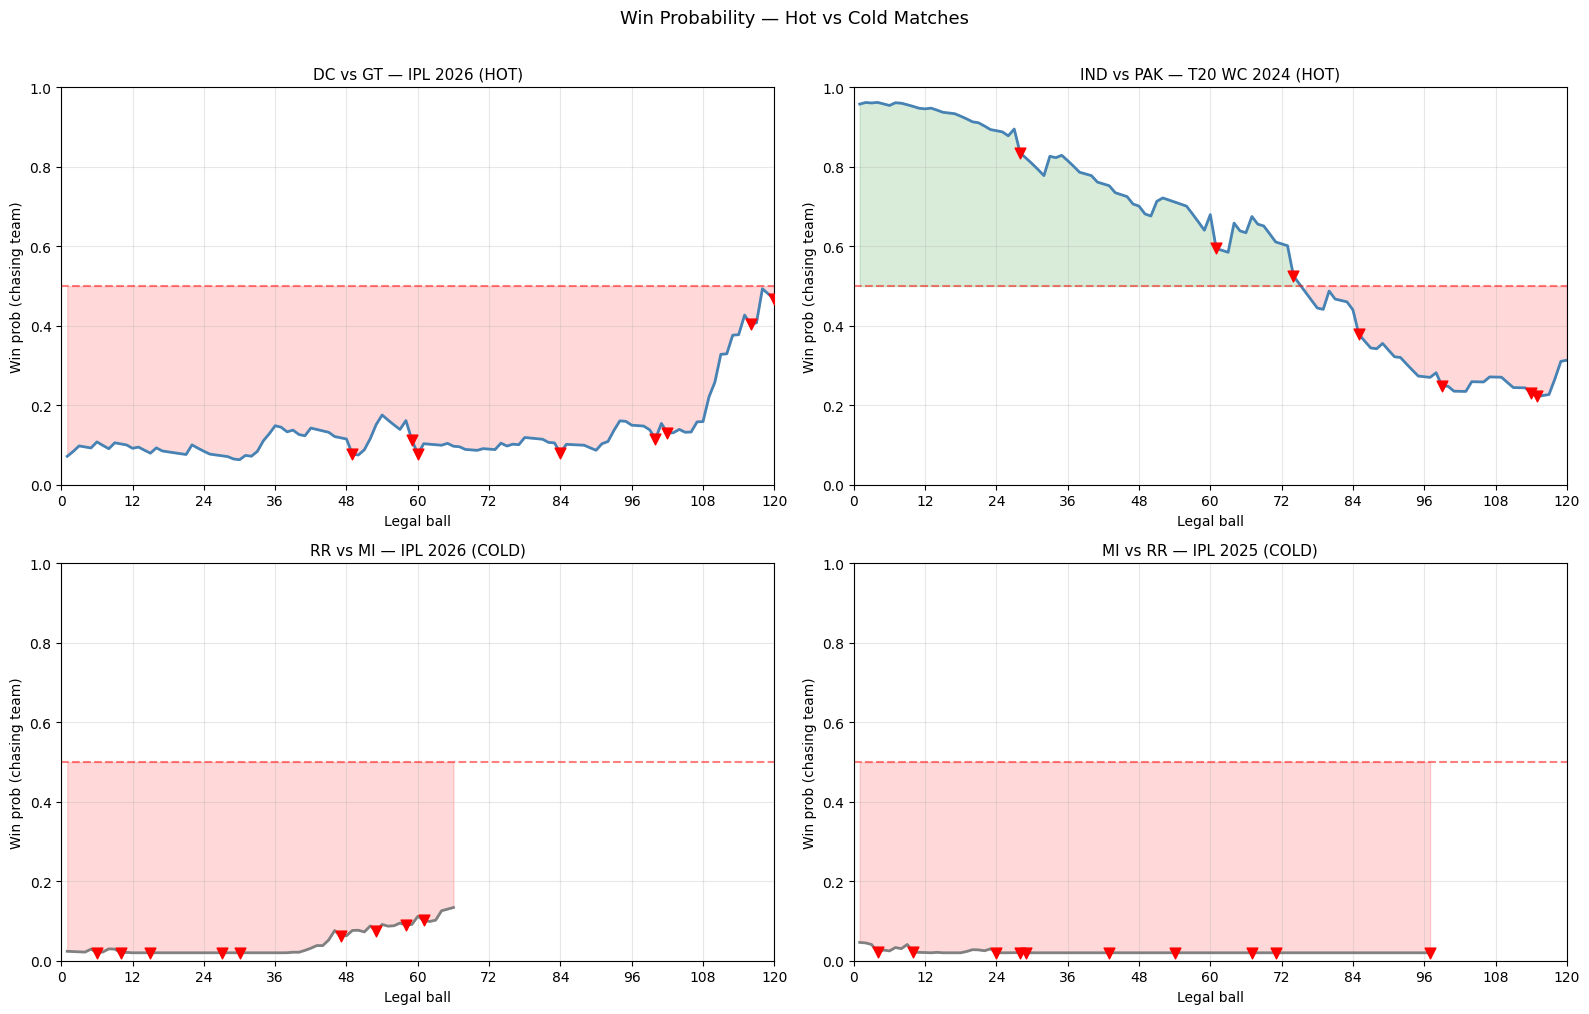

In [5]:
ALL_MATCHES = [
    (dc_gt_chase,  dc_gt_target,  'DC vs GT — IPL 2026 (HOT)',       'steelblue'),
    (ind_pak_chase, ind_pak_target, 'IND vs PAK — T20 WC 2024 (HOT)', 'steelblue'),
    (rr_mi_chase,  rr_mi_target,  'RR vs MI — IPL 2026 (COLD)',       'gray'),
    (mi_rr_chase,  mi_rr_target,  'MI vs RR — IPL 2025 (COLD)',       'gray'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (chase, target, title, color) in zip(axes, ALL_MATCHES):
    ax.plot(chase['legal_ball'], chase['win_prob'], color=color, linewidth=2)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50/50')
    ax.fill_between(chase['legal_ball'], chase['win_prob'], 0.5,
                    where=chase['win_prob'] >= 0.5, alpha=0.15, color='green')
    ax.fill_between(chase['legal_ball'], chase['win_prob'], 0.5,
                    where=chase['win_prob'] < 0.5, alpha=0.15, color='red')
    wicket_balls = chase[chase['is_wicket']]
    ax.scatter(wicket_balls['legal_ball'], wicket_balls['win_prob'],
               color='red', zorder=5, s=60, marker='v')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Win prob (chasing team)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 120)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))

plt.suptitle('Win Probability — Hot vs Cold Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'win_prob_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2: Hotness Score Through the Chase

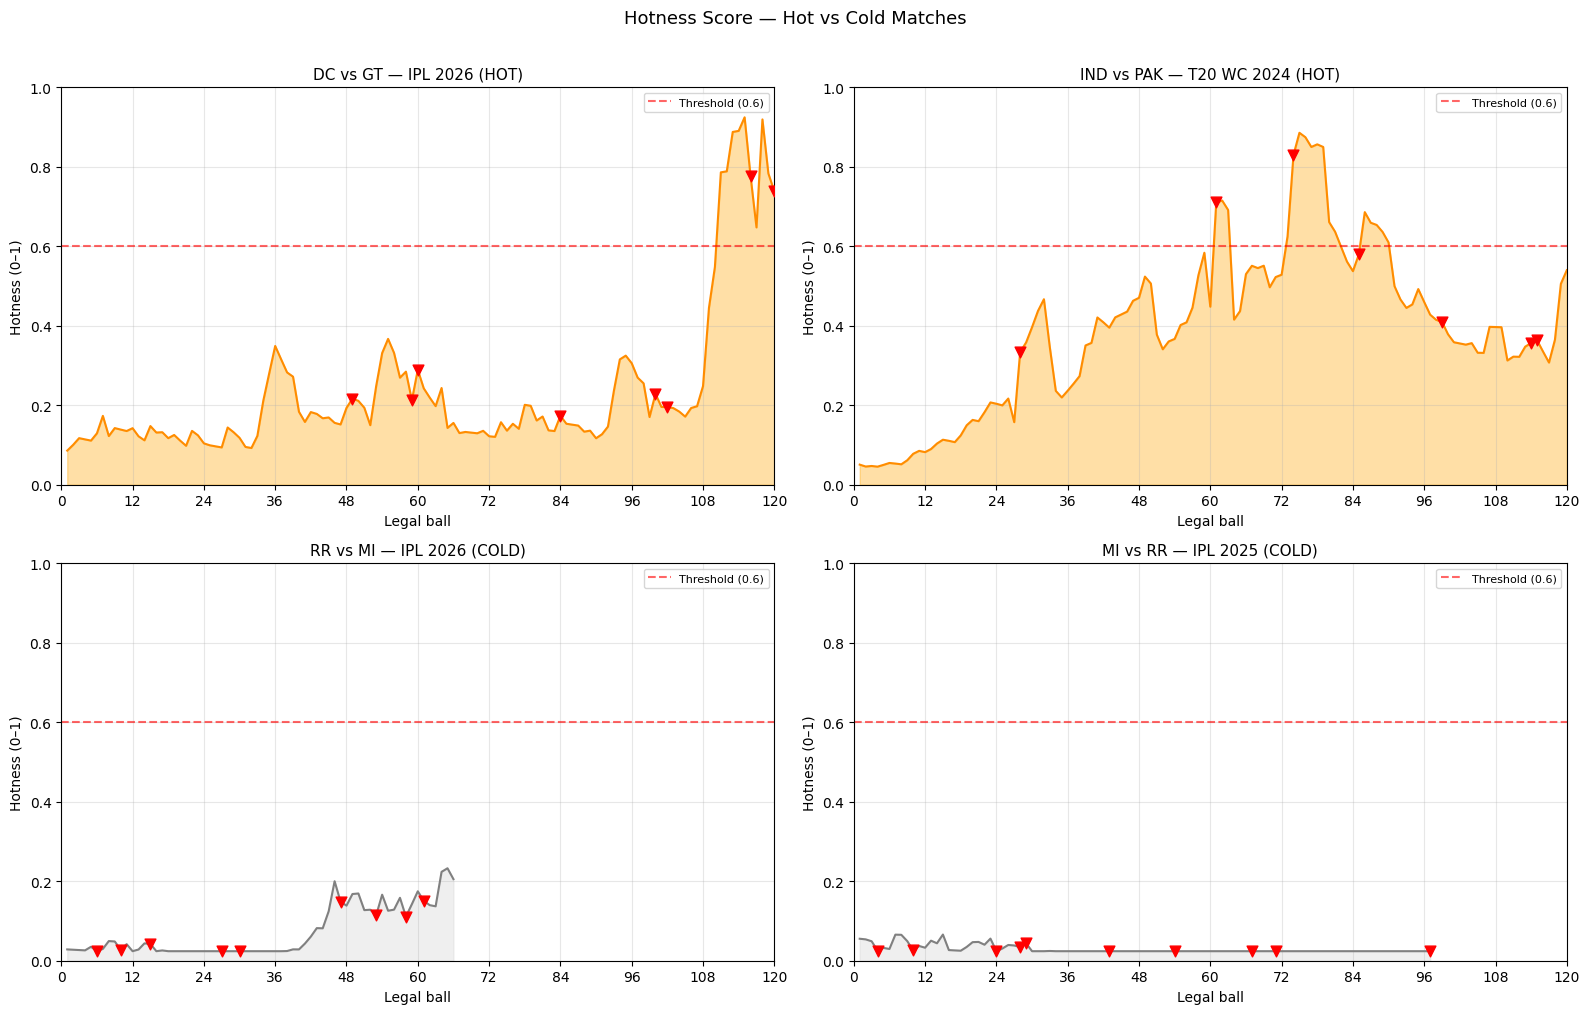

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (chase, target, title, color) in zip(axes, ALL_MATCHES):
    ax.fill_between(chase['legal_ball'], chase['hotness'], alpha=0.35, color='orange' if 'HOT' in title else 'lightgray')
    ax.plot(chase['legal_ball'], chase['hotness'], color='darkorange' if 'HOT' in title else 'gray', linewidth=1.5)
    ax.axhline(0.6, color='red', linestyle='--', alpha=0.6, label='Threshold (0.6)')
    wicket_balls = chase[chase['is_wicket']]
    ax.scatter(wicket_balls['legal_ball'], wicket_balls['hotness'],
               color='red', zorder=5, s=60, marker='v')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Hotness (0–1)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 120)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=8)

plt.suptitle('Hotness Score — Hot vs Cold Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hotness_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3: Required Run Rate vs Current Run Rate

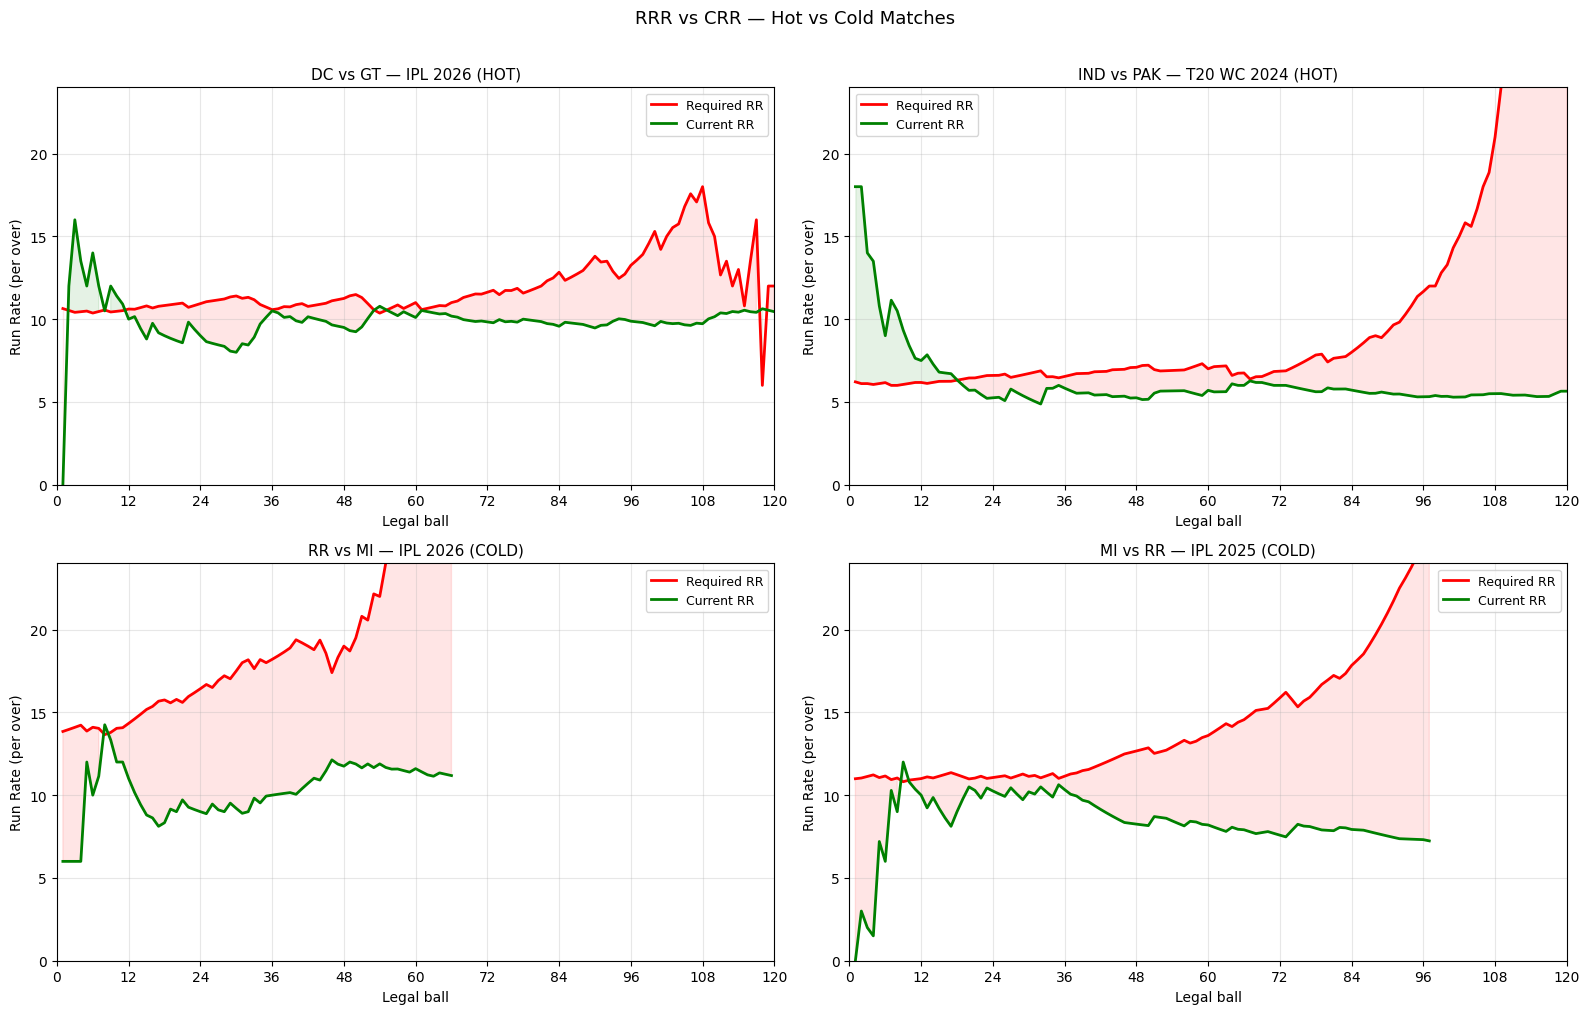

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (chase, target, title, color) in zip(axes, ALL_MATCHES):
    ax.plot(chase['legal_ball'], chase['rrr'] * 6, label='Required RR', color='red', linewidth=2)
    ax.plot(chase['legal_ball'], chase['crr'] * 6, label='Current RR', color='green', linewidth=2)
    ax.fill_between(chase['legal_ball'], chase['rrr']*6, chase['crr']*6,
                    where=chase['rrr'] >= chase['crr'], alpha=0.1, color='red')
    ax.fill_between(chase['legal_ball'], chase['rrr']*6, chase['crr']*6,
                    where=chase['rrr'] < chase['crr'], alpha=0.1, color='green')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Run Rate (per over)')
    ax.set_ylim(0, 24)
    ax.set_xlim(0, 120)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=9)

plt.suptitle('RRR vs CRR — Hot vs Cold Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## When Did These Matches 'Turn On'?

Find the first ball where hotness crosses 0.55 and stays elevated — the 'tune in now' moment.

In [8]:
def find_heat_onset(chase, threshold=0.55, sustained_balls=6):
    """Find first ball where hotness >= threshold for at least sustained_balls."""
    hot = chase['hotness'] >= threshold
    for i in range(len(hot) - sustained_balls):
        if hot.iloc[i:i+sustained_balls].all():
            ball = chase['legal_ball'].iloc[i]
            over = (ball - 1) // 6 + 1
            return ball, over, chase.iloc[i]
    return None, None, None

for chase, label, _, tag in [
    (dc_gt_chase,  'DC vs GT',  dc_gt_target,  'HOT'),
    (ind_pak_chase,'IND vs PAK',ind_pak_target, 'HOT'),
    (rr_mi_chase,  'RR vs MI',  rr_mi_target,  'COLD'),
    (mi_rr_chase,  'MI vs RR',  mi_rr_target,  'COLD'),
]:
    ball, over, row = find_heat_onset(chase)
    if ball:
        balls_left = 120 - ball
        print(f"[{tag}] {label}: Heat onset at ball {ball} (over {over}), {balls_left} balls remaining")
        print(f"  Score: {int(row['score'])}/{int(row['wickets_fallen'])}, "
              f"Need: {int(row['runs_needed'])} off {int(row['balls_remaining'])} balls, "
              f"Win prob: {row['win_prob']:.2f}, Hotness: {row['hotness']:.2f}")
    else:
        print(f"[{tag}] {label}: Never sustained hotness above threshold")
    print()

[HOT] DC vs GT: Heat onset at ball 111 (over 19), 9 balls remaining
  Score: 192/6, Need: 19 off 9 balls, Win prob: 0.33, Hotness: 0.79

[HOT] IND vs PAK: Heat onset at ball 73 (over 13), 47 balls remaining
  Score: 73/2, Need: 47 off 41 balls, Win prob: 0.60, Hotness: 0.63

[COLD] RR vs MI: Never sustained hotness above threshold

[COLD] MI vs RR: Never sustained hotness above threshold



## Summary Stats

In [9]:
print(f"{'Match':<25} {'Label':<6} {'Target':>7} {'Balls':>6} {'Final':>10} {'MaxHot':>8} {'Balls>0.5':>10} {'Balls>0.7':>10} {'MaxMom':>8}")
print("-" * 95)

for chase, label, target, balls, tag in [
    (dc_gt_chase,  'DC vs GT',  dc_gt_target,  dc_gt_balls,  'HOT'),
    (ind_pak_chase,'IND vs PAK',ind_pak_target, ind_pak_balls,'HOT'),
    (rr_mi_chase,  'RR vs MI',  rr_mi_target,  rr_mi_balls,  'COLD'),
    (mi_rr_chase,  'MI vs RR',  mi_rr_target,  mi_rr_balls,  'COLD'),
]:
    final = f"{int(chase['score'].iloc[-1])}/{int(chase['wickets_fallen'].iloc[-1])}"
    print(f"{label:<25} {tag:<6} {target:>7} {balls:>6} {final:>10} "
          f"{chase['hotness'].max():>8.3f} "
          f"{(chase['hotness'] > 0.5).sum():>10} "
          f"{(chase['hotness'] > 0.7).sum():>10} "
          f"{chase['momentum_shift_6'].max():>8.3f}")

Match                     Label   Target  Balls      Final   MaxHot  Balls>0.5  Balls>0.7   MaxMom
-----------------------------------------------------------------------------------------------
DC vs GT                  HOT        211    120      209/8    0.925         11          9    0.219
IND vs PAK                HOT        120    114      113/7    0.886         33          8    0.161
RR vs MI                  COLD       151     66      123/9    0.233          0          0    0.054
MI vs RR                  COLD       218    120     117/10    0.066          0          0    0.021
